<a href="https://colab.research.google.com/github/williamtheodoruswijaya/semantix/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture

!pip install torch torchvision torchaudio
!pip install segmentation-models-pytorch timm
!pip install albumentations opencv-python pillow pandas scikit-learn tqdm scipy

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import cv2

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import os
import zipfile
import random
import json
from pathlib import Path
from tqdm import tqdm

In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

## Import Dataset

- Unzip dataset

In [4]:
os.makedirs("/content/flopwd_data", exist_ok=True)

with zipfile.ZipFile("/content/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025).zip", "r") as zip_ref:
  zip_ref.extractall("/content/flopwd_data")

- Get Images

In [5]:
raw_images = sorted(list(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Raw_Images").glob("*")))
mask_images = sorted(list(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Segmentation_Masks").glob("*")))
labels_csv = Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Image_labels_Binary Classification Task.csv")
reg_csv = Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Mask_foreground_percentages_Regression Task.csv")

In [6]:
labels_df = pd.read_csv(labels_csv)
reg_df = pd.read_csv(reg_csv)

In [7]:
labels_df.head()

,image name,Presence of plastic waste?
0,img1.jpg,yes
1,img2.jpg,yes
2,img3.jpg,yes
3,img4.jpg,yes
4,img5.jpg,yes


In [8]:
reg_df.head()

,image name,plastic waste accumulation (in percentage)
0,img1.jpg,0.08
1,img2.jpg,0.03
2,img3.jpg,0.38
3,img4.jpg,0.20
4,img5.jpg,0.18


### Transform Dataset

In [9]:
labels_df = labels_df.rename(columns={
    "image name": "image_name",
    "Presence of plastic waste?": "presence"
})

reg_df = reg_df.rename(columns={
    "image name": "image_name",
    "plastic waste accumulation (in percentage)": "fg_pct"
})

df = labels_df.merge(reg_df, on="image_name", how="inner")

df["image_path"] = df["image_name"].apply(lambda x: str(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Raw_Images") / x))
df["mask_name"] = df["image_name"].str.replace(".jpg", "_mask.png", regex=False)
df["mask_path"] = df["mask_name"].apply(lambda x: str(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Segmentation_Masks") / x))

df["presence"] = df["presence"].astype(str).str.strip().str.lower()
df["has_plastic"] = (df["presence"] == "yes").astype(int)

df.head()

,image_name,presence,fg_pct,image_path,mask_name,mask_path,has_plastic
0,img1.jpg,yes,0.08,/content/flopwd_data/Dal Lake Floating Plastic...,img1_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
1,img2.jpg,yes,0.03,/content/flopwd_data/Dal Lake Floating Plastic...,img2_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
2,img3.jpg,yes,0.38,/content/flopwd_data/Dal Lake Floating Plastic...,img3_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
3,img4.jpg,yes,0.20,/content/flopwd_data/Dal Lake Floating Plastic...,img4_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
4,img5.jpg,yes,0.18,/content/flopwd_data/Dal Lake Floating Plastic...,img5_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1


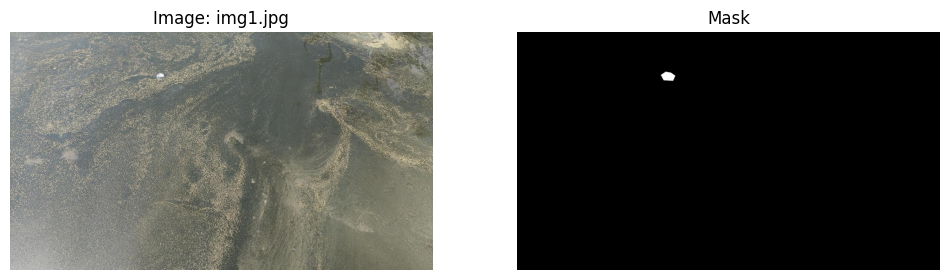

In [10]:
row = df.iloc[0]
image = cv2.imread(row["image_path"])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Image: {row['image_name']}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

## Data Splitting (70:15:15)

In [11]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["has_plastic"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["has_plastic"]
)

In [12]:
# reset
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Train: 1445
Val  : 256
Test : 301


## Data Preprocessing

### Image Augmentation

In [13]:
IMAGE_HEIGHT = 448
IMAGE_WIDTH = 800

In [14]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

In [15]:
# transform only training and validation images

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.3),

    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),

    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### Image Preprocessing (Class & Dataloader)

In [16]:
class PlasticDataset(Dataset):
  def __init__(self, dataframe, transforms=None):
    self.dataframe = dataframe
    self.transforms = transforms

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    row = self.dataframe.iloc[idx]
    image = cv2.imread(row["image_path"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    mask = (mask > 127).astype(np.float32)  # 0=background, 1=plastic

    if self.transforms:
      transformed = self.transforms(image=image, mask=mask)
      image = transformed["image"]
      mask = transformed["mask"]

    mask = mask.unsqueeze(0)  # [1, H, W]
    fg_pct = torch.tensor(float(row["fg_pct"]), dtype=torch.float32)

    return image, mask, fg_pct

In [17]:
train_dataset = PlasticDataset(train_df, transforms=train_transform)
val_dataset = PlasticDataset(val_df, transforms=val_transform)
test_dataset = PlasticDataset(test_df, transforms=val_transform)

In [18]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

## Modelling

In [19]:
%%capture

model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

## Training

#### Training Hyperparameter

In [20]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEVICE

'cuda'

In [21]:
model = model.to(DEVICE)

#### Loss Function

##### Pos Weight Estimation for Class Imbalance Handlign

For Give more loss if positive pixel are predicted falsely (FP)

In [22]:
pos_pixels = 0
neg_pixels = 0

# step 1: sampling sebanyak 200
subset = train_df.sample(min(200, len(train_df)), random_state=42)

for _, row in subset.iterrows():
  mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
  mask = (mask > 127).astype(np.uint8)

  pos_pixels += mask.sum()
  neg_pixels += mask.size - mask.sum()

pos_weight = neg_pixels / max(pos_pixels, 1)

pos_weight

np.float64(17.441991871195814)

##### BCE

Loss function for Clasification per pixel

In [23]:
bce_loss = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=DEVICE)
)

##### DICE

Loss function for Mask Overlapping

In [24]:
dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

#####  Combine

In [25]:
def combined_loss(pred_mask, true_mask, dice_weight=0.6, bce_weight=0.4):
  d_loss = dice_loss(pred_mask, true_mask)
  b_loss = bce_loss(pred_mask, true_mask)
  return dice_weight * d_loss + bce_weight * b_loss

#### Optimizer

In [26]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4 # ini anggep aja regularizationnya ges
)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

/tmp/ipykernel_6767/2394790339.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


#### Metric

In [27]:
def apply_sigmoid(x):
    return torch.sigmoid(x)


def binarize_mask(prob_mask, threshold=0.5):
    return (prob_mask > threshold).float()


def compute_fg_percentage(mask_tensor):
    """[B, 1, H, W] binary float → 1-D tensor of fg% per image (0–100)."""
    B = mask_tensor.shape[0]
    total_pixels = mask_tensor.shape[2] * mask_tensor.shape[3]
    fg_counts = mask_tensor.view(B, -1).sum(dim=1)
    return (fg_counts / total_pixels) * 100.0


def compute_epoch_stats(all_preds, all_targets, eps=1e-7):
    """Accumulate TP/FP/FN over FULL epoch tensors, then compute metrics once."""
    preds = all_preds.float()
    targets = all_targets.float()
    tp = (preds * targets).sum()
    fp = (preds * (1 - targets)).sum()
    fn = ((1 - preds) * targets).sum()
    iou = (tp + eps) / (tp + fp + fn + eps)
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    return {
        "iou": iou.item(),
        "dice": dice.item(),
        "precision": precision.item(),
        "recall": recall.item(),
    }


def compute_pct_metrics(pred_pcts, gt_pcts):
    """MAE, RMSE, bias, Pearson R, R², MAPE (skip gt==0 for MAPE)."""
    pred = np.array(pred_pcts, dtype=np.float64)
    gt = np.array(gt_pcts, dtype=np.float64)
    mae = np.mean(np.abs(pred - gt))
    rmse = np.sqrt(np.mean((pred - gt) ** 2))
    bias = np.mean(pred - gt)
    r, _ = pearsonr(pred, gt) if len(pred) > 1 else (float("nan"), None)
    r2 = r2_score(gt, pred) if len(pred) > 1 else float("nan")
    nonzero = gt != 0
    mape = (
        np.mean(np.abs((pred[nonzero] - gt[nonzero]) / gt[nonzero]) * 100)
        if nonzero.any()
        else float("nan")
    )
    return {
        "mae_pct": float(mae),
        "rmse_pct": float(rmse),
        "bias_pct": float(bias),
        "pearson_r": float(r),
        "r2": float(r2),
        "mape_pct": float(mape),
    }

In [30]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc="Training", leave=False)

    for images, masks, _ in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = model(images)
            loss = combined_loss(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    return running_loss / len(loader)

In [31]:
def validate_one_epoch(model, loader, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_masks = []
    pred_pcts = []
    gt_pcts_csv = []

    with torch.no_grad():
        for images, masks, fg_pct in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(images)
            loss = combined_loss(logits, masks)
            running_loss += loss.item()

            probs = apply_sigmoid(logits)
            preds = binarize_mask(probs, threshold=threshold)

            all_preds.append(preds.cpu())
            all_masks.append(masks.cpu())

            batch_pred_pcts = compute_fg_percentage(preds.cpu())
            pred_pcts.extend(batch_pred_pcts.tolist())
            gt_pcts_csv.extend(fg_pct.tolist())

    all_preds = torch.cat(all_preds, dim=0)
    all_masks = torch.cat(all_masks, dim=0)

    seg_stats = compute_epoch_stats(all_preds, all_masks)
    pct_stats = compute_pct_metrics(pred_pcts, gt_pcts_csv)

    return {
        "loss": running_loss / len(loader),
        **seg_stats,
        **pct_stats,
    }

In [32]:
def find_best_threshold(model, loader, device):
    thresholds = np.arange(0.10, 0.91, 0.05)
    best_threshold = 0.5
    best_mae = float("inf")

    model.eval()

    all_probs = []
    all_masks = []
    gt_pcts_csv = []

    with torch.no_grad():
        for images, masks, fg_pct in tqdm(loader, desc="Collecting val probs", leave=False):
            images = images.to(device)
            logits = model(images)
            probs = torch.sigmoid(logits).cpu()
            all_probs.append(probs)
            all_masks.append(masks.cpu())
            gt_pcts_csv.extend(fg_pct.tolist())

    all_probs = torch.cat(all_probs, dim=0)
    all_masks = torch.cat(all_masks, dim=0)
    gt_pcts = np.array(gt_pcts_csv)

    for threshold in thresholds:
        preds = (all_probs > threshold).float()
        pred_pcts = compute_fg_percentage(preds).numpy()
        mae = np.mean(np.abs(pred_pcts - gt_pcts))
        if mae < best_mae:
            best_mae = mae
            best_threshold = threshold

    return best_threshold, best_mae

#### Training

In [33]:
best_val_mae = float("inf")
best_model_path = "/content/best_flopwd_unetplusplus.pth"

history = []

patience = 8
counter = 0

for epoch in range(30):
    print(f"\nEpoch [{epoch+1}/{30}]")

    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)

    best_threshold, _ = find_best_threshold(model, val_loader, DEVICE)
    val_metrics = validate_one_epoch(model, val_loader, DEVICE, threshold=best_threshold)

    print(f"Train Loss     : {train_loss:.4f}")
    print(f"Val Loss       : {val_metrics['loss']:.4f}")
    print(f"--- Secondary ---")
    print(f"Val IoU        : {val_metrics['iou']:.4f}")
    print(f"Val Dice       : {val_metrics['dice']:.4f}")
    print(f"Val Precision  : {val_metrics['precision']:.4f}")
    print(f"Val Recall     : {val_metrics['recall']:.4f}")
    print(f"--- Primary ---")
    print(f"Val MAE pct    : {val_metrics['mae_pct']:.4f}")
    print(f"Val RMSE pct   : {val_metrics['rmse_pct']:.4f}")
    print(f"Val Bias pct   : {val_metrics['bias_pct']:.4f}")
    print(f"Val Pearson R  : {val_metrics['pearson_r']:.4f}")
    print(f"Val R²         : {val_metrics['r2']:.4f}")
    print(f"Best Threshold : {best_threshold:.2f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_iou": val_metrics["iou"],
        "val_dice": val_metrics["dice"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_mae_pct": val_metrics["mae_pct"],
        "val_rmse_pct": val_metrics["rmse_pct"],
        "val_bias_pct": val_metrics["bias_pct"],
        "val_pearson_r": val_metrics["pearson_r"],
        "val_r2": val_metrics["r2"],
        "best_threshold": float(best_threshold),
    })

    if val_metrics["mae_pct"] < best_val_mae:
        best_val_mae = val_metrics["mae_pct"]
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")
        counter = 0
    else:
        counter += 1
        print(f"No improvement. Patience counter: {counter}/{patience}")

    if counter >= patience:
        print("Early stopping triggered.")
        break


Epoch [1/30]


Training:   0%|          | 0/362 [00:00<?, ?it/s]/tmp/ipykernel_6767/2539086823.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


Train Loss   : 0.7054
Val Loss     : 0.5798
Val IoU      : 0.3311
Val Dice     : 0.4247
Val Precision: 0.5628
Val Recall   : 0.5912
Best Threshold: 0.90
Best model saved.

Epoch [2/30]


Train Loss   : 0.6504
Val Loss     : 0.6244
Val IoU      : 0.3682
Val Dice     : 0.4424
Val Precision: 0.5103
Val Recall   : 0.6955
Best Threshold: 0.85
Best model saved.

Epoch [3/30]


Train Loss   : 0.6207
Val Loss     : 0.4775
Val IoU      : 0.4393
Val Dice     : 0.5346
Val Precision: 0.5804
Val Recall   : 0.7151
Best Threshold: 0.90
Best model saved.

Epoch [4/30]


...

Train Loss   : 0.3997
Val Loss     : 0.4430
Val IoU      : 0.5523
Val Dice     : 0.6498
Val Precision: 0.7343
Val Recall   : 0.7131
Best Threshold: 0.80
No improvement. Patience counter: 2/8

Epoch [27/30]


Train Loss   : 0.3712
Val Loss     : 0.4155
Val IoU      : 0.5811
Val Dice     : 0.6759
Val Precision: 0.7584
Val Recall   : 0.7218
Best Threshold: 0.85
No improvement. Patience counter: 3/8

Epoch [28/30]


Train Loss   : 0.3459
Val Loss     : 0.3513
Val IoU      : 0.5670
Val Dice     : 0.6617
Val Precision: 0.7340
Val Recall   : 0.7284
Best Threshold: 0.90
No improvement. Patience counter: 4/8

Epoch [29/30]


Train Loss   : 0.3416
Val Loss     : 0.3772
Val IoU      : 0.5465
Val Dice     : 0.6462
Val Precision: 0.6663
Val Recall   : 0.7951
Best Threshold: 0.90
No improvement. Patience counter: 5/8

Epoch [30/30]


Train Loss   : 0.3559
Val Loss     : 0.4327
Val IoU      : 0.5718
Val Dice     : 0.6658
Val Precision: 0.7624
Val Recall   : 0.7192
Best Threshold: 0.90
No improvement. Patience counter: 6/8


##### Training History

In [34]:
history_df = pd.DataFrame(history)
history_df.to_csv("/content/flopwd_training_history.csv", index=False)
history_df.tail()

,epoch,train_loss,val_loss,val_iou,val_dice,val_precision,val_recall,best_threshold
25,26,0.399658,0.442977,0.552265,0.649807,0.734322,0.713111,0.80
26,27,0.371202,0.415509,0.581094,0.675946,0.758356,0.721792,0.85
27,28,0.345870,0.351313,0.566951,0.661713,0.734014,0.728440,0.90
28,29,0.341630,0.377179,0.546489,0.646198,0.666318,0.795133,0.90
29,30,0.355923,0.432679,0.571782,0.665820,0.762399,0.719167,0.90


##### Best Model

In [35]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

<All keys matched successfully>

##### Best Threshold

In [36]:
best_threshold, best_mae = find_best_threshold(model, val_loader, DEVICE)

#### Evaluation

In [ ]:
test_metrics = validate_one_epoch(model, test_loader, DEVICE, threshold=best_threshold)

print("\n=== TEST METRICS ===")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

In [ ]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Train loss vs val loss
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# 2. Primary: val_mae_pct + val_rmse_pct
axes[1].plot(history_df["epoch"], history_df["val_mae_pct"], label="Val MAE (%)")
axes[1].plot(history_df["epoch"], history_df["val_rmse_pct"], label="Val RMSE (%)")
axes[1].set_title("Primary Metrics: MAE & RMSE (fg%)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Percentage Points")
axes[1].legend()

# 3. Primary: val_r2 + val_pearson_r
axes[2].plot(history_df["epoch"], history_df["val_r2"], label="Val R²")
axes[2].plot(history_df["epoch"], history_df["val_pearson_r"], label="Val Pearson R")
axes[2].set_title("Primary Metrics: R² & Pearson R")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Score")
axes[2].legend()

plt.tight_layout()
plt.savefig("/content/flopwd_training_history_plots.png", dpi=150)
plt.show()

In [ ]:
model.eval()
scatter_pred_pcts = []
scatter_gt_pcts = []

with torch.no_grad():
    for images, masks, fg_pct in tqdm(test_loader, desc="Scatter inference", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        probs = apply_sigmoid(logits)
        preds = binarize_mask(probs, threshold=best_threshold)
        batch_pred_pcts = compute_fg_percentage(preds.cpu())
        scatter_pred_pcts.extend(batch_pred_pcts.tolist())
        scatter_gt_pcts.extend(fg_pct.tolist())

plt.figure(figsize=(8, 8))
plt.scatter(scatter_gt_pcts, scatter_pred_pcts, alpha=0.6, edgecolors="k", linewidths=0.5)
max_val = max(max(scatter_gt_pcts, default=1), max(scatter_pred_pcts, default=1))
plt.plot([0, max_val], [0, max_val], "r--", label="Perfect prediction")
plt.xlabel("Ground Truth fg% (from CSV)")
plt.ylabel("Predicted fg% (from mask)")
plt.title("Predicted vs Ground Truth Foreground Percentage")
plt.legend()
plt.tight_layout()
plt.savefig("/content/flopwd_scatter_plot.png", dpi=150)
plt.show()

In [ ]:
model.eval()
worst_pred_pcts = []
worst_gt_pcts = []

with torch.no_grad():
    for images, masks, fg_pct in tqdm(test_loader, desc="Worst predictions", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        probs = apply_sigmoid(logits)
        preds = binarize_mask(probs, threshold=best_threshold)
        batch_pred_pcts = compute_fg_percentage(preds.cpu()).tolist()
        worst_pred_pcts.extend(batch_pred_pcts)
        worst_gt_pcts.extend(fg_pct.tolist())

errors_df = pd.DataFrame({
    "image_name": test_df["image_name"].values,
    "gt%": worst_gt_pcts,
    "pred%": worst_pred_pcts,
})
errors_df["abs_error"] = (errors_df["pred%"] - errors_df["gt%"]).abs()

worst = errors_df.sort_values("abs_error", ascending=False).head(10)
worst = worst[["image_name", "gt%", "pred%", "abs_error"]]

print("Top 10 Worst Predictions by Absolute fg% Error:")
print(worst.to_string(index=False, float_format="{:.2f}".format))

- Result

In [ ]:
with open("/content/flopwd_test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=4)

print("Test metrics saved.")

#### Inferences

In [ ]:
def denormalize_image(image_tensor, mean, std):
    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    image = image * np.array(std) + np.array(mean)
    image = np.clip(image, 0, 1)
    return image

def show_predictions(model, dataset, device, threshold=0.5, num_samples=5):
    model.eval()
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    plt.figure(figsize=(15, num_samples * 5))

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask, _ = dataset[idx]

            input_tensor = image.unsqueeze(0).to(device)
            logits = model(input_tensor)
            probs = torch.sigmoid(logits)
            pred = (probs > threshold).float()

            image_np = denormalize_image(image, mean, std)
            mask_np = mask.squeeze(0).cpu().numpy()
            pred_np = pred.squeeze().cpu().numpy()

            plt.subplot(num_samples, 3, i * 3 + 1)
            plt.imshow(image_np)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(num_samples, 3, i * 3 + 2)
            plt.imshow(mask_np, cmap="gray")
            plt.title("Ground Truth")
            plt.axis("off")

            plt.subplot(num_samples, 3, i * 3 + 3)
            plt.imshow(pred_np, cmap="gray")
            plt.title("Prediction")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

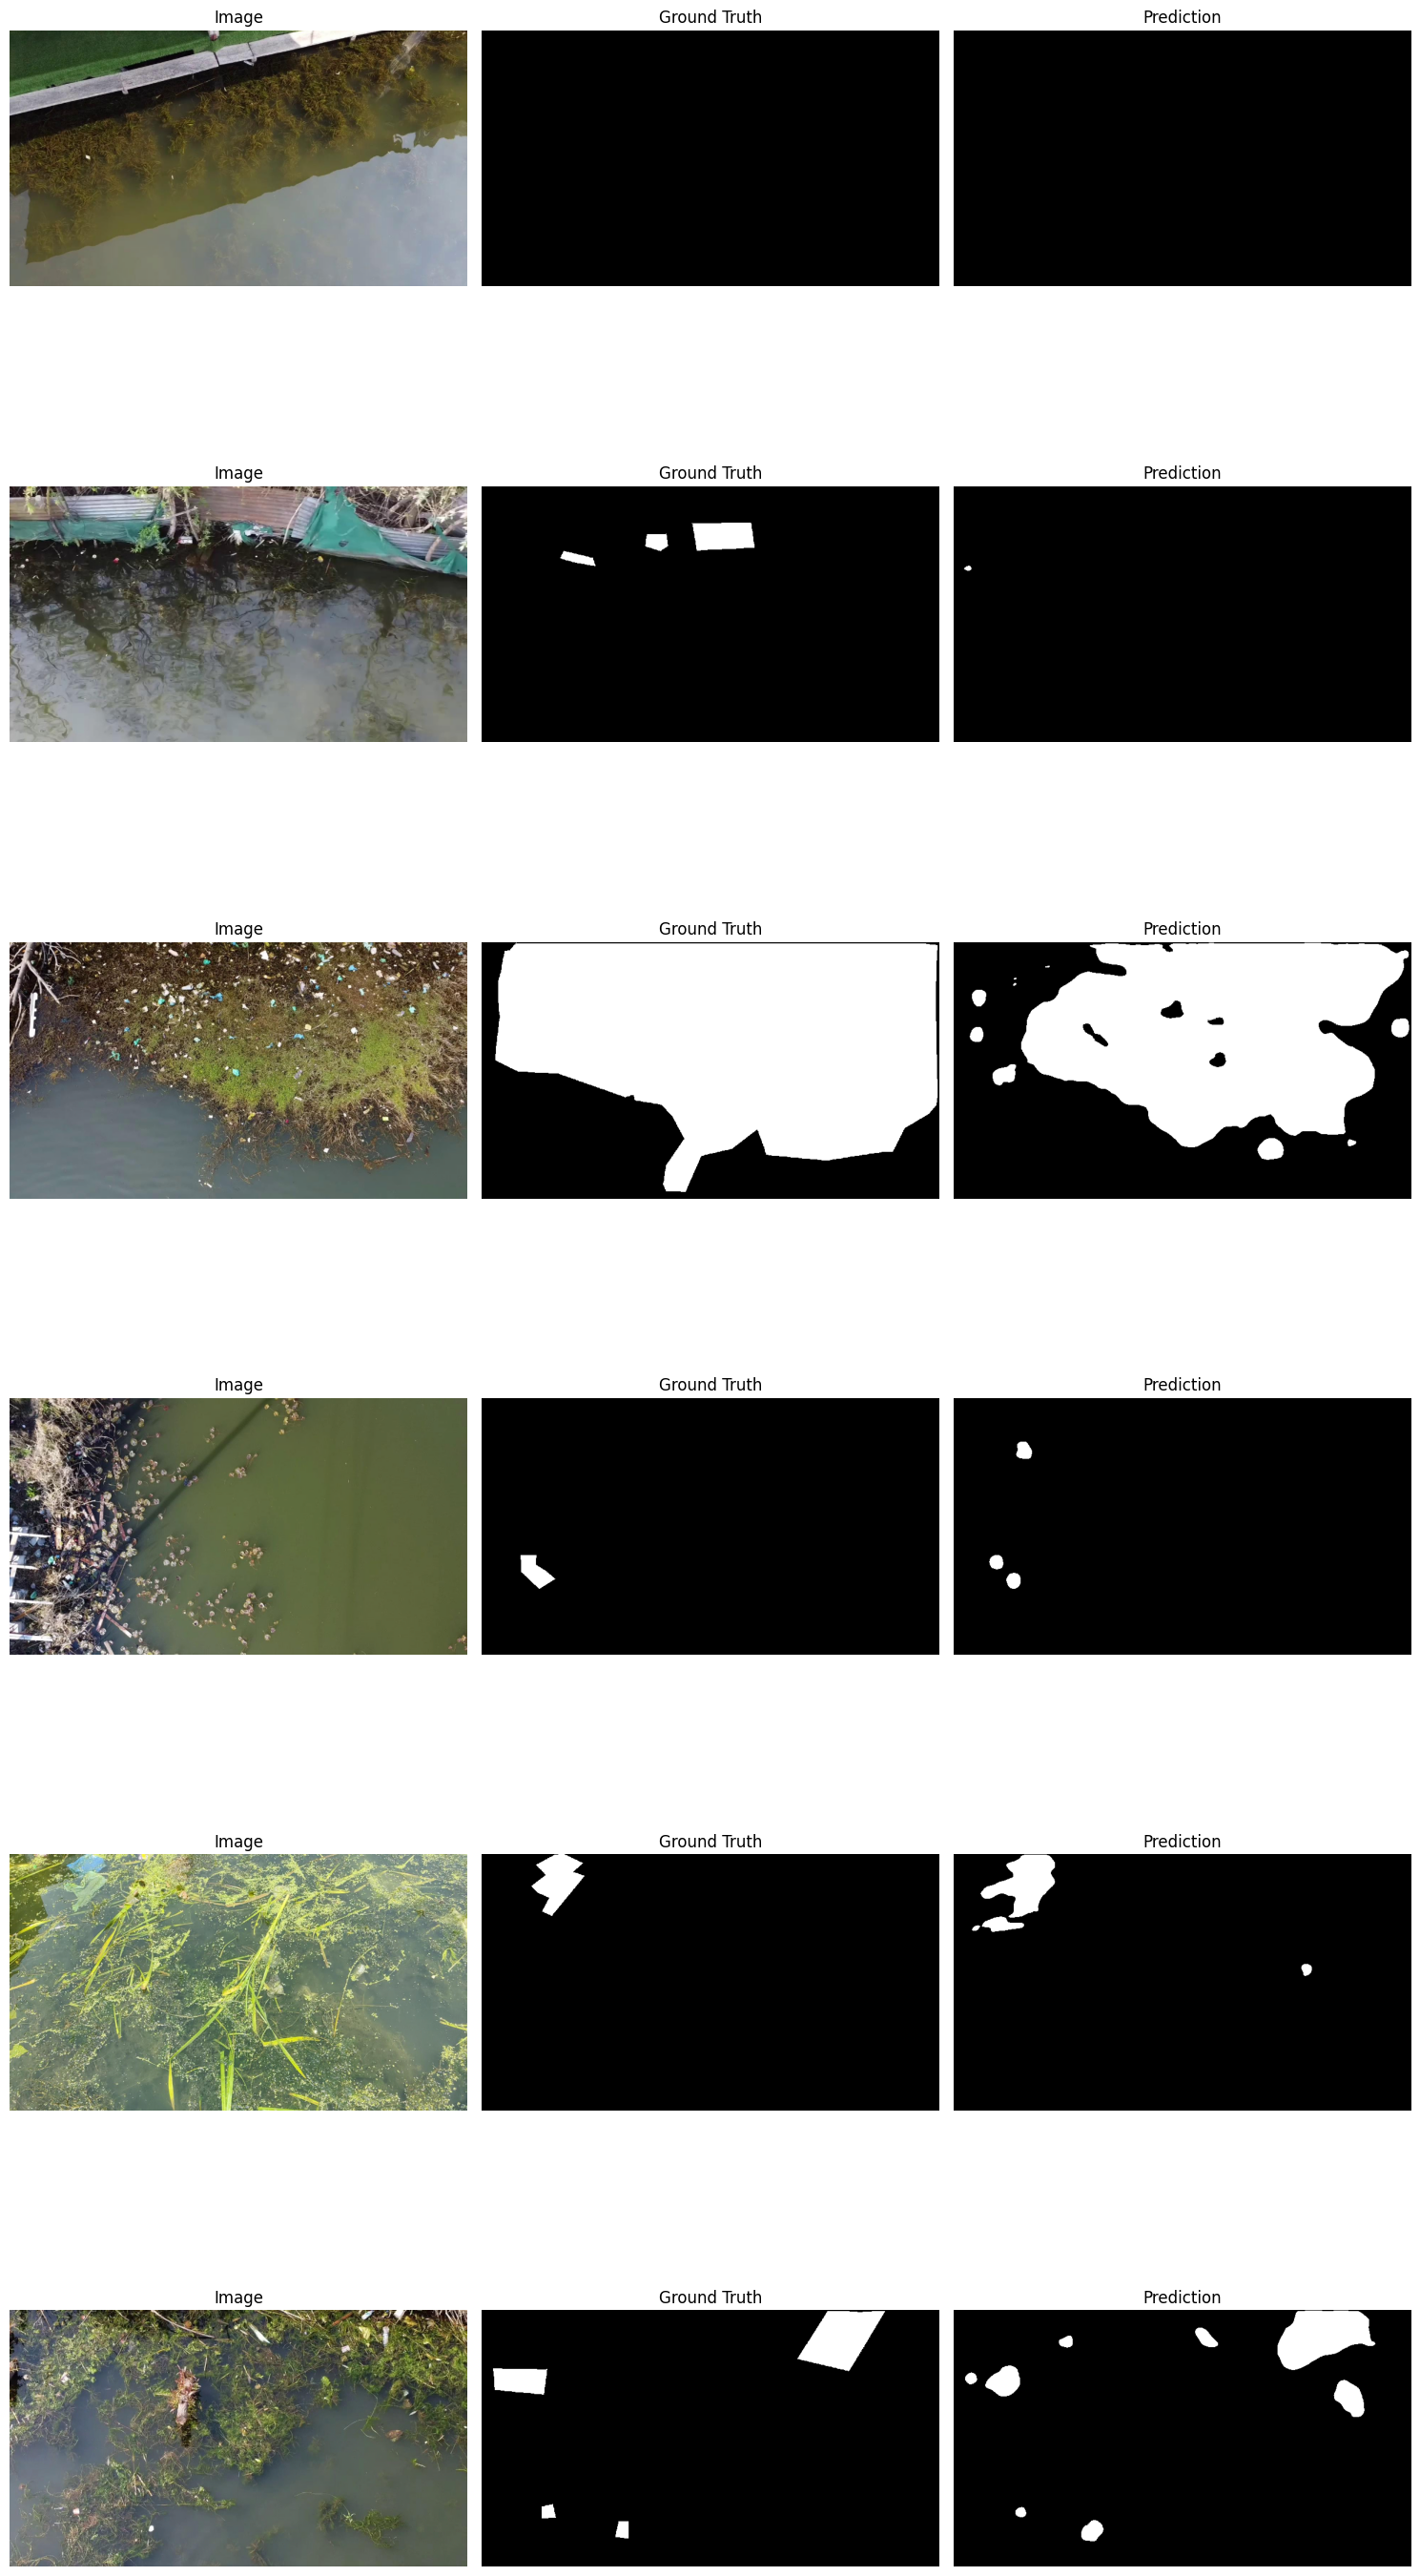

In [40]:
show_predictions(model, test_dataset, DEVICE, threshold=best_threshold, num_samples=6)